In [14]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score

In [16]:
x, y = make_classification(n_samples=200, n_features=2, n_informative=2,n_redundant=0, n_classes=2,
                           n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=5)

Text(0.5, 1.0, 'Binary Classification Dataset')

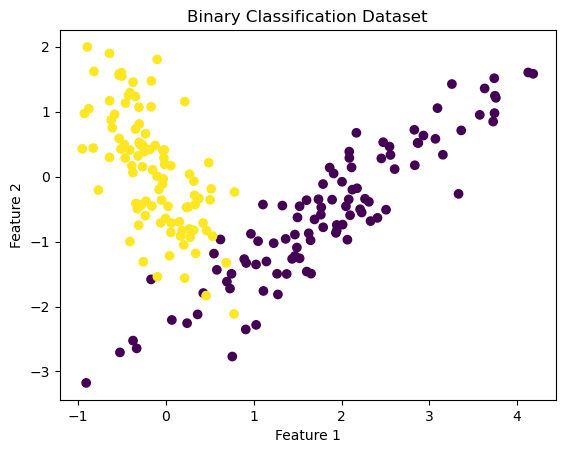

In [17]:
plt.figure()
plt.scatter(x[:, 0], x[:, 1], c=y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Binary Classification Dataset")

In [18]:
poly = PolynomialFeatures(degree=2, include_bias=False)
x_trf = poly.fit_transform(x)

In [19]:
lr = LogisticRegression()
np.mean(cross_val_score(lr, x_trf, y, scoring='accuracy', cv=5))

np.float64(0.97)

In [20]:
def plot_decision_boundary(X,y,degree=1):
    
    poly = PolynomialFeatures(degree=degree)
    X_trf = poly.fit_transform(X)
    
    clf = LogisticRegression()
    clf.fit(X_trf,y)
    
    accuracy = np.mean(cross_val_score(clf,X_trf,y,scoring='accuracy',cv=10))
    
    a=np.arange(start=X[:,0].min()-1, stop=X[:,0].max()+1, step=0.01)
    b=np.arange(start=X[:,1].min()-1, stop=X[:,1].max()+1, step=0.01)


    XX,YY=np.meshgrid(a,b)
    
    input_array=np.array([XX.ravel(),YY.ravel()]).T

    labels=clf.predict(poly.transform(input_array))
    
    plt.contourf(XX,YY,labels.reshape(XX.shape),alpha=0.5)
    plt.scatter(X[:,0],X[:,1], c=y)
    plt.title('Degree = {}, accuracy is {}'.format(degree,np.round(accuracy,4)))

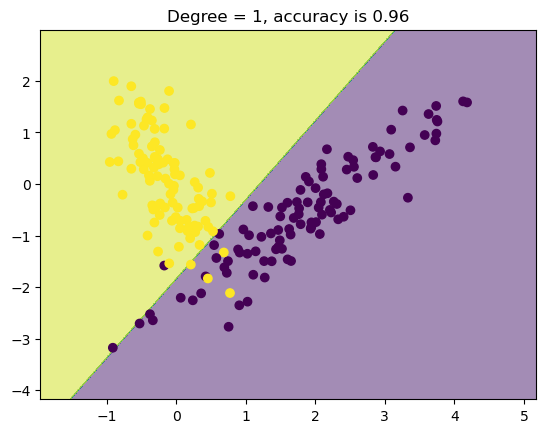

In [22]:
plot_decision_boundary(x, y)

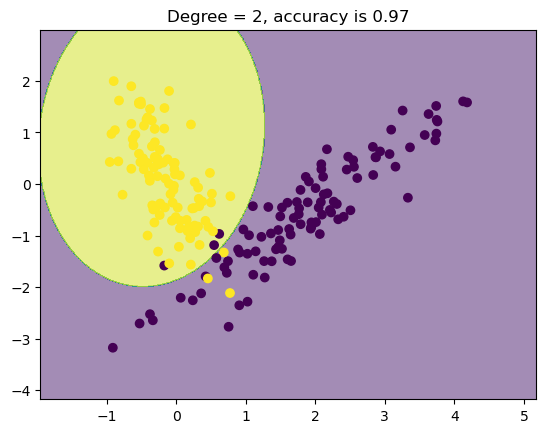

In [23]:
plot_decision_boundary(x, y, 2)

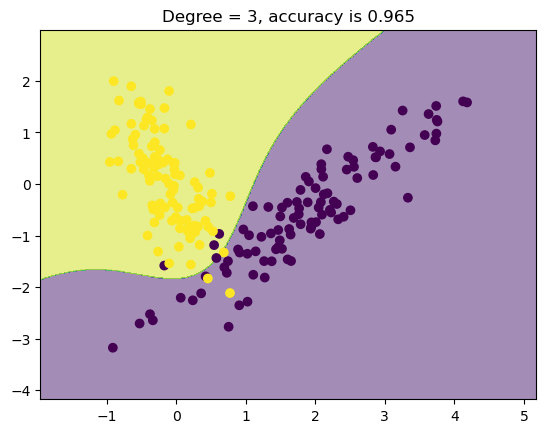

In [24]:
plot_decision_boundary(x, y, 3)

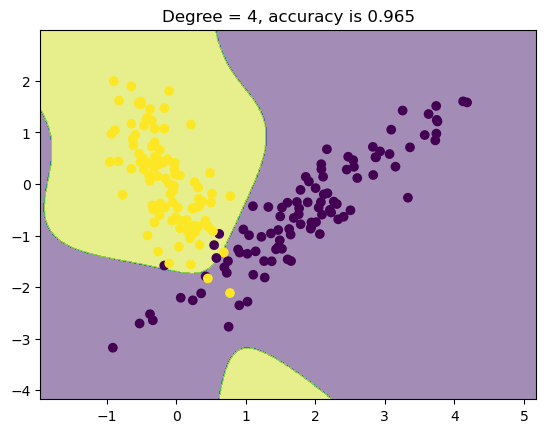

In [25]:
plot_decision_boundary(x, y, 4)